# FOC Monte Carlo, and two sensorless observers

Three parts, in this order:

1. **Five sensorless observers**, each simulated over drawn plants and ranked by what they measure rather than by reputation: the **Sliding Mode Observer (SMO)**, the **Flux Linkage Observer** with the **Extended Back-EMF Observer** as its close relative, the **Extended State Observer (ESO / ADRC)**, the **Adaptive Luenberger Observer** and the **Dual Flux Linkage Observer**. Then the hybrid that blends two of them, and what the flux magnitude measures about the machine itself.
2. **The firmware's own control law**, searched over the 23-63 V link sweep with `tools/montecarlo.py`.
3. **The envelope** both land in: speed, torque, the thermal ceiling, and reference values for an outrunner or another low-saliency machine.

No board.

In [1]:
SIMULATED = True          # False, and PORT, at the bench
PORT = 'COM4'

`tools/montecarlo.py` runs the firmware's own C - the current loop, the injection demodulator, the rotor observer, the dead-time table - through `test_drive_core.py`'s bench against `drive_model.c`, one process per core. A plant is drawn around the 5230SL that the controller was not told about; the cost is `sigma_theta + speed_err + 10 trip`.

In [2]:
import os
import sys

sys.path.insert(0, os.path.join('..', 'host', 'tools'))
import montecarlo as mc

print('link sweep', mc.VDC_SWEEP)
print('knobs', {k: v[:2] for k, v in mc.KNOBS.items()})
print('I_MAX %.0f  I_TRIP %.0f  I_H_MAX %.0f  TOP %.2f  LOST %.2f rad'
      % (mc.I_MAX, mc.I_TRIP, mc.I_H_MAX, mc.TOP, mc.LOST))
plant = mc.draw(1, 43.0)
print({k: round(v, 6) for k, v in plant.items()})

link sweep (23.0, 33.0, 43.0, 53.0, 63.0)
knobs {'bw_i': (300.0, 2500.0), 'f_pll': (20.0, 400.0), 'zeta': (0.5, 1.2), 'v_inj': (0.02, 0.2), 'n_inj': (1, 4), 'w_lo': (50.0, 800.0), 'w_ratio': (1.5, 4.0), 'bw_w': (1.0, 20.0)}
I_MAX 60  I_TRIP 100  I_H_MAX 5  TOP 0.50  LOST 0.35 rad
{'r': 0.039602, 'ld': 1.8e-05, 'lq': 2.1e-05, 'lambda': 0.002071, 'pole_pairs': 14.0, 'sat': 0.3, 'i_sat': 40.0, 'j': 0.000141, 'b': 0.000253, 'load': 0.0, 'v_dt': 0.082524, 'i_knee': 11.289512, 'vdc': 43.0, 'noise': 0.355632, 'theta0': 0.178112, 'sub': 4.0, 'theta_err0': 0.805836, 'k_prop': 5e-06}


## Part 1: five sensorless observers

The firmware holds the rotor at rest by injecting and demodulating, and blends to back-EMF above `w_lo`. Everything in this part is about that upper half: five observers, all in `coaxial.sensorless`, all fed by nothing but the phase voltages and currents, all run over plants drawn with the same tolerances the search uses in part 2.

The sweep below runs the two oldest side by side - sliding mode and flux linkage - and the sections that follow take each observer on its own before all five are ranked together.

In [3]:
import math
from coaxial import inverter, sensorless
from coaxial.loop import CurrentLoop, Machine, Signals
from coaxial.motor import PLATINUM_5230SL, Parameters

TWO_PI = 2.0 * math.pi
motor = PLATINUM_5230SL
SPEEDS = (20.0, 50.0, 100.0, 200.0, 500.0, 1000.0, 2000.0)
PLANTS = 5
#: Where the blend hands over from sliding mode to flux linkage, rad/s
#: electrical - a band about the crossover, not a threshold.
BLEND_BAND = (400.0, 1400.0)

def observe(plant, w_e, seconds=0.4):
    """Both observers against a rotor held at w_e, error in degrees rms."""
    fitted = Parameters(name='drawn', r=plant['r'], ld=plant['ld'],
                        lq=plant['lq'], lam=plant['lambda'],
                        poles=int(plant['pole_pairs']), measured=False)
    dt = 2.0 * inverter.TS
    loop = CurrentLoop(hz=800.0, motor=fitted, vdc=plant['vdc'])
    machine = Machine(fitted, vdc=plant['vdc'], noise=plant['noise'], sub=4,
                      locked=True)
    machine.motor.omega = w_e
    smo = sensorless.SlidingModeObserver(
        fitted.r, fitted.ld, k=1.5 * fitted.lam * abs(w_e) + 1.0)
    flux = sensorless.FluxObserver(fitted.r, fitted.ld, wc=20.0)
    s = Signals()
    s.iq_ref = 2.0
    got = {'smo': [], 'flux': [], 'gap': [], 'blend': []}
    # Each observer's own residual - no truth in either. The sliding-mode
    # observer is only estimating anything while its model current is on
    # the measured one; the flux observer's rotor flux should have the
    # magnitude lambda, and does not when the integrator has drifted.
    res = {'smo': [], 'flux': []}
    rows = []
    for step in range(int(seconds / dt)):
        s.t = step * dt
        loop(s, dt)
        machine(s, dt)
        c, sn = math.cos(s.theta), math.sin(s.theta)
        va, vb = s.vd * c - s.vq * sn, s.vd * sn + s.vq * c
        ia, ib = s.id * c - s.iq * sn, s.id * sn + s.iq * c
        th_s = smo.update(va, vb, ia, ib, dt)
        th_f = flux.update(va, vb, ia, ib, dt)
        if s.t > 0.5 * seconds:
            got['smo'].append(sensorless._wrap(th_s - s.theta))
            got['flux'].append(sensorless._wrap(th_f - s.theta))
            got['gap'].append(sensorless._wrap(th_s - th_f))
            res['smo'].append(math.hypot(smo.i_alpha - ia, smo.i_beta - ib)
                              / max(plant['noise'], 1e-3))
            psi = math.hypot(flux.psi_alpha - fitted.ld * ia,
                             flux.psi_beta - fitted.ld * ib)
            res['flux'].append(abs(psi - fitted.lam) / fitted.lam)
            rows.append((th_s, th_f, s.theta, abs(smo.omega)))
    # The blend, ramped over BLEND_BAND on the observer's own speed and
    # applied to the unit vectors - an angle is not a quantity you
    # average. All sliding mode below the band, all flux above it.
    lo, hi = BLEND_BAND
    share = 0.0
    for th_s, th_f, truth, w in rows:
        f = min(1.0, max(0.0, (w - lo) / (hi - lo)))
        x = (1.0 - f) * math.cos(th_s) + f * math.cos(th_f)
        y = (1.0 - f) * math.sin(th_s) + f * math.sin(th_f)
        got['blend'].append(sensorless._wrap(math.atan2(y, x) - truth))
        share += (1.0 - f) / len(rows)
    out = {k: math.degrees(math.sqrt(sum(e * e for e in v) / len(v)))
           for k, v in got.items()}
    out['share'] = share
    out['res_smo'] = sum(res['smo']) / len(res['smo'])
    out['res_flux'] = sum(res['flux']) / len(res['flux'])
    return out

plants = [mc.draw(90 + i, 43.0) for i in range(PLANTS)]
print('  rad/s el    rpm      SMO deg rms       flux deg rms     apart   blend')
print('                     median  worst     median  worst       deg  median')
table = []
for w_e in SPEEDS:
    rows = [observe(p, w_e) for p in plants]
    def column(key):
        return sorted(r[key] for r in rows)
    smo, flux = column('smo'), column('flux')
    gap, blend, share = column('gap'), column('blend'), column('share')
    table.append((w_e, smo, flux, gap, blend, share,
                  column('res_smo'), column('res_flux')))
    print('%10.0f %6.0f %11.1f %6.1f %10.1f %6.1f %9.1f %7.1f'
          % (w_e, w_e / motor.poles * 60.0 / TWO_PI,
             smo[len(smo) // 2], smo[-1], flux[len(flux) // 2], flux[-1],
             gap[len(gap) // 2], blend[len(blend) // 2]))

  rad/s el    rpm      SMO deg rms       flux deg rms     apart   blend
                     median  worst     median  worst       deg  median


        20     14        18.5   19.6       52.9   53.0      55.1    18.5


        50     34         7.4    7.8       36.0   36.1      36.4     7.4


       100     68         4.3    4.8       23.3   23.3      23.4     4.3


       200    136         2.7    3.0       12.0   12.0      11.9     2.7


       500    341         2.2    2.2        5.4    5.4       5.7     2.1


      1000    682         3.0    3.1        3.5    3.5       4.9     2.2


      2000   1364         5.5    5.7        3.2    3.3       7.4     3.2


A torque command at an angle error of `eps` delivers `cos(eps)` of itself: 20 degrees electrical costs 6 %, 40 degrees costs 23 %. Taking 20 degrees as the line each has to stay inside:

In [4]:
CRITERION_DEG = 20.0
COLUMN = {'smo': 1, 'flux': 2, 'blend': 4}

def band_of(which):
    """(lowest, highest) swept speed whose worst plant is inside it."""
    inside = [row[0] for row in table if row[COLUMN[which]][-1] <= CRITERION_DEG]
    return (min(inside), max(inside)) if inside else (None, None)

def rpm(w_e):
    return w_e / motor.poles * 60.0 / TWO_PI

for which, name in (('smo', 'sliding mode'), ('flux', 'flux linkage'),
                    ('blend', 'the two blended')):
    lo, hi = band_of(which)
    print('%-14s inside %.0f deg from %5.0f to %5.0f rad/s = %4.0f to %5.0f rpm'
          % (name, CRITERION_DEG, lo, hi, rpm(lo), rpm(hi)))

sliding mode   inside 20 deg from    20 to  2000 rad/s =   14 to  1364 rpm
flux linkage   inside 20 deg from   200 to  2000 rad/s =  136 to  1364 rpm
the two blended inside 20 deg from    20 to  2000 rad/s =   14 to  1364 rpm


## Sliding Mode Observer (SMO)

The stator's current equation run as a model, with a switching term driving the model's current onto the measured one. Once it slides, that term is the only thing the model was missing, which is the back-EMF; low-passing it is the estimate, and `e = lambda w (-sin, cos)` gives the angle.

`k` has to exceed the back-EMF the machine can make, so it is sized from `lambda w` rather than tuned. It degrades at **both** ends and for different reasons: low down the back-EMF is small against `R i` and the boundary layer, so the error grows as the signal shrinks; high up the lag `atan(w/wc)` becomes a large correction - 76 degrees at 2000 rad/s with `wc` 500 - and a large correction rests heavily on the speed estimate under it.

It needs R and L and is the least sensitive of the two to them: the switching term absorbs what the model gets wrong, which is the point of it.

In [5]:
print('sliding mode, deg rms, over %d drawn plants' % PLANTS)
print('  rad/s el    rpm    median   worst   current residual, in sigma_i')
for row in table:
    w_e, smo, res = row[0], row[1], row[6]
    print('%10.0f %6.0f %9.1f %7.1f %19.2f'
          % (w_e, rpm(w_e), smo[len(smo) // 2], smo[-1], res[len(res) // 2]))
lo, hi = band_of('smo')
print()
print('inside %.0f deg from %.0f rpm to %.0f rpm' % (CRITERION_DEG, rpm(lo), rpm(hi)))

sliding mode, deg rms, over 5 drawn plants
  rad/s el    rpm    median   worst   current residual, in sigma_i
        20     14      18.5    19.6                3.64
        50     34       7.4     7.8                3.93
       100     68       4.3     4.8                4.57
       200    136       2.7     3.0                5.86
       500    341       2.2     2.2               10.47
      1000    682       3.0     3.1               17.78
      2000   1364       5.5     5.7               33.82

inside 20 deg from 14 rpm to 1364 rpm


## Flux Linkage Observer

`psi = integral of (v - R i)` is the stator's flux linkage and `psi - L i` is the rotor's, whose angle is the rotor's. Nothing is differentiated and nothing switches, so it is quiet where it works.

The integrator is the whole difficulty. A pure one walks away on any offset in v, in the current, or in R, so this leaks at `wc` - which costs exactly what it saves: the estimate comes out `sqrt(1 + (wc/w)^2)` short and `atan(wc/w)` late, and the correction is only as good as the speed it rests on. At `w = wc` that correction is 45 degrees, and below it the observer has nothing.

Above the corner it is the better of the two by a growing margin: no lag worth compensating, and **lambda falls out of it**. The rotor flux's magnitude should be lambda, so the observer can check itself without a reference - which the sliding-mode observer cannot do from its angle alone.

## Extended Back-EMF Observer

The flux observer's close relative, and what it fixes.

`psi - L i` needs one L, and a salient machine has two. Subtracting Ld along both axes leaves `(Lq - Ld) iq` sitting on the q axis of what is supposed to be the rotor's flux, so the estimate is pulled round by an angle that grows with **load** and vanishes at no load - which is why a flux observer can look perfect on a bench and lose the rotor pulling a propeller.

The extended back-EMF formulation is the same physics arranged so that this cannot happen. Write the stator equation with Ld as the inductance in both axes and everything left over goes into one term:

        E_ex = (Ld - Lq)(w id - d iq/dt) + w lambda

        v = (R + p Ld) i + E_ex (-sin theta, cos theta)

All the position is in `E_ex`, and `E_ex` points along the same axis the plain back-EMF does - so an observer estimating it recovers the angle with no saliency error at all. At `id = 0` and steady speed the saliency terms drop out and `E_ex = w lambda`, which is why the two agree at no load and part company under it.

It costs one extra term and gives back the load error below.

In [6]:
print('what one L costs the flux observer under load, 5230SL')
print('Ld %.1f uH, Lq %.1f uH, saliency %.2f, lambda %.5f Wb'
      % (motor.ld * 1e6, motor.lq * 1e6, motor.saliency, motor.lam))
print()
print('   iq A   (Lq-Ld) iq uWb   angle error deg   torque lost %')
for iq in (0.0, 2.0, 10.0, 30.0, 60.0, 100.0):
    stray = (motor.lq - motor.ld) * iq
    err = math.atan2(stray, motor.lam)
    print('%7.0f %17.1f %17.2f %13.1f'
          % (iq, stray * 1e6, math.degrees(err),
             100.0 * (1.0 - math.cos(err))))
print()
print('the extended back-EMF form carries the same term instead of')
print('leaving it in the estimate, so its error here is zero at every iq.')

what one L costs the flux observer under load, 5230SL
Ld 22.0 uH, Lq 29.0 uH, saliency 1.32, lambda 0.00207 Wb

   iq A   (Lq-Ld) iq uWb   angle error deg   torque lost %
      0               0.0              0.00           0.0
      2              14.0              0.39           0.0
     10              70.0              1.93           0.1
     30             210.0              5.79           0.5
     60             420.0             11.46           2.0
    100             700.0             18.66           5.3

the extended back-EMF form carries the same term instead of
leaving it in the estimate, so its error here is zero at every iq.


At the 2 A the sweep above runs, the error is a fifth of a degree and invisible - which is exactly how this gets missed. At the current the board is rated for it is not small, and it is a **bias**, not noise: it does not average out, and it moves with torque, so a speed loop chasing it sees the machine's own gain change.

Nothing here implements the extended form; `sensorless.FluxObserver` is the plain one, and its saliency error is the table above. On a surface-magnet outrunner - saliency near 1 - the two forms coincide and the plain observer is the right one. The more saliency a machine has, the more the injection has to work with at rest and the more the flux observer needs the extended form at speed, which is the same constant paying twice in opposite directions.

In [7]:
print('flux linkage, deg rms, over %d drawn plants' % PLANTS)
print('  rad/s el    rpm    median   worst   wc/w correction   |psi| off lambda')
for row in table:
    w_e, flux, res = row[0], row[2], row[7]
    print('%10.0f %6.0f %9.1f %7.1f %13.1f deg %15.1f %%'
          % (w_e, rpm(w_e), flux[len(flux) // 2], flux[-1],
             math.degrees(math.atan2(20.0, w_e)), 100.0 * res[len(res) // 2]))
lo, hi = band_of('flux')
print()
print('inside %.0f deg from %.0f rpm to %.0f rpm' % (CRITERION_DEG, rpm(lo), rpm(hi)))

flux linkage, deg rms, over 5 drawn plants
  rad/s el    rpm    median   worst   wc/w correction   |psi| off lambda
        20     14      52.9    53.0          45.0 deg            30.7 %
        50     34      36.0    36.1          21.8 deg             7.8 %
       100     68      23.3    23.3          11.3 deg             2.1 %
       200    136      12.0    12.0           5.7 deg             0.8 %
       500    341       5.4     5.4           2.3 deg             0.7 %
      1000    682       3.5     3.5           1.1 deg             0.6 %
      2000   1364       3.2     3.3           0.6 deg             0.6 %

inside 20 deg from 136 rpm to 1364 rpm


## Extended State Observer (ESO / ADRC)

The one that refuses to model anything. `di/dt = v/L + f`, and `f` is everything else at once - the resistive drop, the back-EMF, the parameter error, the switching pickup, whatever the sense chain does. ADRC estimates `f` as a state instead of separating them, so there is **no low-pass on the signal it wants**, and nothing in its angle rests on the speed it is estimating.

That is the argument for it, and it is a good one: the lag correction is what makes the SMO stiff at the top and the flux observer worthless at the bottom. One knob, the observer bandwidth `wo`, with both poles placed there - `beta1 = 2 wo`, `beta2 = wo^2`.

The catch is that `wo` has to sit above the electrical frequency and below what the step can integrate. At the drive's 20 us and an explicit step, `wo` past about 12 000 rad/s is where the second pole stops being stable - and 12 000 is only six times the 2 000 rad/s at the top of this sweep. It has the bandwidth for the middle and runs out at both ends, which the numbers below show plainly.

## Adaptive Luenberger observer

A current observer whose back-EMF is an integrator on the current error, with R adapted from the part of that error lying along the current. The point is thermal: a winding rises about 0.4 % per kelvin, every observer here integrates `v - R i`, and the R they were handed at commissioning is not the R an hour of load leaves behind.

As a back-EMF observer it behaves like one - poor at rest, best of all five at the top of the sweep. **The adaptation does not converge in this arrangement**, and the measurement below says so rather than the prose hiding it: `e_hat` and `r_hat` feed on one residual, `e_hat` is three orders faster, and what is left for `r_hat` is not a clean function of the R error. Low-passing the projection to separate the timescales moves R the wrong way; raising the gain diverges.

What that says is that R needs an excitation the back-EMF cannot explain - a d-axis current the rotor does not answer - which is exactly what `commission.deadtime` already does offline, and why it is a commissioning step rather than a loop.

## Dual Flux Linkage Observer

Two flux models correcting each other. The voltage model `integral of (v - R i)` is right at speed and drifts at rest; the current model `L i + lambda` is right at rest and wrong wherever L or lambda are. Feeding the difference back into the integrator is what holds the DC down - the current model, not a high-pass, so there is no leak to correct for and no `atan(wc/w)` to pay.

The angle comes off a **PLL** rather than an `atan2` of the flux. An `atan2` passes every bit of flux noise into the angle and, through the difference, into the speed; the PLL is second order with the angle as its state, so the speed falls out of the loop instead of out of a subtraction.

It measures best of the five below, and by a wide margin where the others struggle. The condition is that the PLL is running - handed the speed it had a moment ago, the way a drive hands its observer the previous estimate. From a standing start it has to slew in, which is a lock time rather than an error.

## The five, ranked by measurement

Same plants, same step, same current. The PLL and the speed states start where a running drive would leave them.

In [8]:
from coaxial.motor import Parameters as _P

RANKED = ('dual', 'smo', 'luen', 'eso', 'flux')

def five(fitted, w_e):
    """One of each, with the states a running drive would hand over."""
    made = {
        'eso': sensorless.ExtendedStateObserver(fitted.r, fitted.ld, wo=12000.0),
        'luen': sensorless.AdaptiveLuenberger(fitted.r, fitted.ld),
        'dual': sensorless.DualFluxObserver(fitted.r, fitted.ld, fitted.lam,
                                            cross=20.0),
        'smo': sensorless.SlidingModeObserver(
            fitted.r, fitted.ld, k=1.5 * fitted.lam * abs(w_e) + 1.0),
        'flux': sensorless.FluxObserver(fitted.r, fitted.ld, wc=20.0),
    }
    for one in made.values():
        one.omega = w_e
    return made

def compare(plant, w_e, seconds=1.0, iq=2.0):
    """All five against a rotor held at w_e. Degrees rms."""
    fitted = _P(name='drawn', r=plant['r'], ld=plant['ld'], lq=plant['lq'],
                lam=plant['lambda'], poles=int(plant['pole_pairs']),
                measured=False)
    dt = inverter.TS
    loop = CurrentLoop(hz=800.0, motor=fitted, vdc=plant['vdc'])
    machine = Machine(fitted, vdc=plant['vdc'], noise=plant['noise'], sub=4,
                      locked=True)
    machine.motor.omega = w_e
    made = five(fitted, w_e)
    s = Signals()
    s.iq_ref = iq
    err = {k: [] for k in made}
    for step in range(int(seconds / dt)):
        s.t = step * dt
        loop(s, dt)
        machine(s, dt)
        c, sn = math.cos(s.theta), math.sin(s.theta)
        va, vb = s.vd * c - s.vq * sn, s.vd * sn + s.vq * c
        ia, ib = s.id * c - s.iq * sn, s.id * sn + s.iq * c
        for name, one in made.items():
            th = one.update(va, vb, ia, ib, dt)
            if s.t > 0.5 * seconds:
                err[name].append(sensorless._wrap(th - s.theta))
    return {k: math.degrees(math.sqrt(sum(e * e for e in v) / len(v)))
            for k, v in err.items()}

ranked = []
print('deg rms, median of %d plants, iq 2 A' % PLANTS)
print('  rad/s el    rpm ' + ''.join('%8s' % n for n in RANKED))
for w_e in (20.0, 100.0, 500.0, 2000.0):
    rows = [compare(p, w_e) for p in plants]
    got = {}
    for name in RANKED:
        v = sorted(r[name] for r in rows)
        got[name] = v[len(v) // 2]
    ranked.append((w_e, got))
    print('%10.0f %6.0f ' % (w_e, rpm(w_e))
          + ''.join('%8.1f' % got[n] for n in RANKED))
print()
for name in RANKED:
    worst = max(row[1][name] for row in ranked)
    best = min(row[1][name] for row in ranked)
    print('%-6s %5.1f deg at its best, %5.1f at its worst' % (name, best, worst))

deg rms, median of 5 plants, iq 2 A
  rad/s el    rpm     dual     smo    luen     eso    flux


        20     14      0.7     8.9    84.0    61.2    52.6


       100     68      0.7     2.0    26.5    11.0    23.1


       500    341      1.1     1.0     4.7     4.9     5.2


      2000   1364      3.5     2.5     1.8    17.0     2.4

dual     0.7 deg at its best,   3.5 at its worst
smo      1.0 deg at its best,   8.9 at its worst
luen     1.8 deg at its best,  84.0 at its worst
eso      4.9 deg at its best,  61.2 at its worst
flux     2.4 deg at its best,  52.6 at its worst


The ranking that comes out is not the one the literature's reputations suggest, and it is worth saying which parts are the method and which are this bench.

**Dual flux with a PLL wins**, and by an order of magnitude where the others are weakest. It is the only one of the five with neither a lag to correct nor a leak to pay for, and the PLL keeps its speed out of a difference. That is a property of the arrangement, not of this simulation.

**The sliding-mode observer is the solid one** across the whole range and the cheapest to reason about, which is why it is the classic. **The adaptive Luenberger** is the best of the five at the top and useless at the bottom - a back-EMF observer behaving like one.

**The ESO comes last here, and that is this bench.** Its case is sound: no filter, so no lag, so nothing resting on its own speed. But the bandwidth that buys has to fit inside a 20 us explicit step, and at 12 000 rad/s it is only six times the top of the sweep. On a faster loop, or with the observer discretised properly rather than by forward Euler, the argument would be tested differently - what is measured here is an ESO at a bandwidth this step can carry, and that is the number that matters for **this** board.

## Running both, and the hybrid

They fail at opposite ends, so there are three ways to use the pair, in rising order of what they ask for.

**Switch** on speed, with hysteresis. The cheapest and the only one needing no extra state - but a threshold where both are marginal is a threshold the estimate chatters across, and the estimate is what the commutation rests on.

**Blend** over a band on the observer's own speed, the shape the firmware already uses between injection and back-EMF over `w_lo .. w_hi`. The two disagree by a few degrees in the overlap, and a step of that size in the commutation angle is a step in torque, so a ramped weight removes it for the cost of a multiply. The weight is applied to the unit vectors, not to the angles.

**Weight on each observer's own residual.** Neither needs truth to say how it is doing: the sliding-mode observer is estimating nothing unless its model current is on the measured one, and the flux observer's rotor flux should have magnitude lambda. Both columns are printed in the sections above.

In [9]:
print('the blend, %.0f to %.0f rad/s = %.0f to %.0f rpm'
      % (BLEND_BAND[0], BLEND_BAND[1], rpm(BLEND_BAND[0]), rpm(BLEND_BAND[1])))
print('  rad/s el    rpm   SMO share   blend deg rms   best single   gained')
for row in table:
    w_e, smo, flux, blend, share = row[0], row[1], row[2], row[4], row[5]
    single = min(smo[len(smo) // 2], flux[len(flux) // 2])
    got = blend[len(blend) // 2]
    print('%10.0f %6.0f %10.2f %14.1f %13.1f %8.1f %%'
          % (w_e, rpm(w_e), share[len(share) // 2], got, single,
             100.0 * (single - got) / single))
print()
print('cost, per step, against the drive step\'s own %d cycles:' % 2921)
print('   sliding mode   2 integrators, 2 saturations, 2 low-passes, one atan2')
print('   flux linkage   2 integrators, one atan2, a sqrt and an atan')
print('   the blend      one ramp, two multiplies, one atan2')
print('   headroom       %d cycles a period at %.0f kHz'
      % (2 * 2375 - 2921, 1e-3 / inverter.TS))

the blend, 400 to 1400 rad/s = 273 to 955 rpm
  rad/s el    rpm   SMO share   blend deg rms   best single   gained
        20     14       1.00           18.5          18.5      0.0 %
        50     34       1.00            7.4           7.4      0.0 %
       100     68       1.00            4.3           4.3      0.0 %
       200    136       1.00            2.7           2.7      0.0 %
       500    341       0.90            2.1           2.2      4.2 %
      1000    682       0.40            2.2           3.0     25.1 %
      2000   1364       0.00            3.2           3.2      0.0 %

cost, per step, against the drive step's own 2921 cycles:
   sliding mode   2 integrators, 2 saturations, 2 low-passes, one atan2
   flux linkage   2 integrators, one atan2, a sqrt and an atan
   the blend      one ramp, two multiplies, one atan2
   headroom       1829 cycles a period at 50 kHz


The blend is not a compromise between the two - in the overlap it beats both, because the two errors are not the same error. One is a lag correction resting on a speed estimate; the other is an integrator's leak. Averaging two partly independent errors is worth more than picking the better one, and the `gained` column is what that is worth here.

Weighting on the residuals instead was tried and **does not work as written**: the sliding-mode observer's current residual is dominated by the AFE's own noise, which its low-pass rejects but the residual still shows, so referring that residual to an angle error over-states it by orders of magnitude and the weight collapses onto the flux observer at every speed. A residual that maps to angle error needs the filter's rejection in it, which is more than a normalisation.

What the residuals are good for as they stand is validity, not weight. The current residual says whether the sliding-mode observer is on its surface at all, and `|psi|` against lambda says whether the flux integrator has drifted - two conditions a speed threshold cannot see, and the same two a supervisor would trip on.

## Maximising what the machine tells you

The angle is not all that is in those residuals. The flux observer's rotor flux has a **magnitude** as well as a direction, and that magnitude is lambda - the one constant that says what the magnets are doing. Nothing else on this board can see them: the NTC is on the PCB, and the rotor is on the other side of an air gap.

So the observer that commutates the machine is also measuring it, for the cost of one `hypot` a step. The question is what corrupts that measurement, and the answer is R: the flux integrates `v - R i`, so an error in R lands in the flux, and it lands hardest where `R i` is a large share of `v` - at low speed.

In [10]:
def identify_lambda(plant, w_e, r_error=0.0, seconds=0.4):
    """What the flux observer's magnitude says lambda is, with R off by
    `r_error` as a fraction. Returns the estimate over the truth."""
    fitted = Parameters(name='drawn', r=plant['r'] * (1.0 + r_error),
                        ld=plant['ld'], lq=plant['lq'], lam=plant['lambda'],
                        poles=int(plant['pole_pairs']), measured=False)
    truth = Parameters(name='truth', r=plant['r'], ld=plant['ld'],
                       lq=plant['lq'], lam=plant['lambda'],
                       poles=int(plant['pole_pairs']), measured=False)
    dt = 2.0 * inverter.TS
    loop = CurrentLoop(hz=800.0, motor=fitted, vdc=plant['vdc'])
    machine = Machine(truth, vdc=plant['vdc'], noise=plant['noise'], sub=4,
                      locked=True)
    machine.motor.omega = w_e
    flux = sensorless.FluxObserver(fitted.r, fitted.ld, wc=20.0)
    s = Signals()
    s.iq_ref = 2.0
    seen = []
    for step in range(int(seconds / dt)):
        s.t = step * dt
        loop(s, dt)
        machine(s, dt)
        c, sn = math.cos(s.theta), math.sin(s.theta)
        va, vb = s.vd * c - s.vq * sn, s.vd * sn + s.vq * c
        ia, ib = s.id * c - s.iq * sn, s.id * sn + s.iq * c
        flux.update(va, vb, ia, ib, dt)
        if s.t > 0.5 * seconds:
            seen.append(math.hypot(flux.psi_alpha - fitted.ld * ia,
                                   flux.psi_beta - fitted.ld * ib))
    return (sum(seen) / len(seen)) / truth.lam

plant = plants[0]
print('lambda recovered from |psi_r|, as a fraction of the truth')
print('  rad/s el    rpm    R exact   R +30 %%   R -30 %%')
for w_e in SPEEDS:
    row = [identify_lambda(plant, w_e, e) for e in (0.0, 0.3, -0.3)]
    print('%10.0f %6.0f %10.3f %9.3f %9.3f' % (w_e, rpm(w_e), row[0], row[1], row[2]))

lambda recovered from |psi_r|, as a fraction of the truth
  rad/s el    rpm    R exact   R +30 %%   R -30 %%
        20     14      0.695     0.317     1.072


        50     34      0.923     0.725     1.121
       100     68      0.979     0.874     1.084


       200    136      0.994     0.941     1.048
       500    341      0.999     0.978     1.020


      1000    682      1.000     0.989     1.010
      2000   1364      1.000     0.994     1.005


Two things fall out of that table, and together they are the procedure.

**Lambda is recoverable at speed and only at speed.** High up, `v` is dominated by the back-EMF and a 30 % error in R barely moves the magnitude; low down, `R i` is most of `v` and the same error swamps it. So the magnet's state is measured where the machine is already turning - which is where it matters, since that is where the flux observer is the one commutating.

**And R is recoverable once lambda is known.** Run it the other way: at low speed, with lambda fixed at what the high-speed measurement said, the magnitude error is a function of R alone. The same observer, the same `hypot`, run at two speeds, separates the two constants that the thermal model most wants - because R is the winding's temperature and lambda is the magnets'.

That is the information the machine gives up for free, and it is worth naming what it buys: the board's thermal observer has one measurement, the NTC, which sits on the PCB in the drivers' hot spot. It estimates the phase node and it cannot see the motor at all. A winding resistance and a magnet flux tracked online are two more anchors, on the other side of the gap, from an observer the drive is running anyway.

## Part 2: the firmware's law over the link sweep

A small search here so the notebook executes in minutes; the tool's defaults are 48 candidates, 16 draws and 24 refinements per link voltage.

In [11]:
import time

VDCS = (23.0, 43.0, 63.0)
t0 = time.perf_counter()
with mc.pool() as p:
    best, runs = mc.search(p, vdcs=VDCS, candidates_n=6, draws=2, refine=3)
    checked = mc.verify(p, best, draws=4)
print('%d runs in %.0f s' % (len(runs) + len(checked), time.perf_counter() - t0))
best[['vdc', 'mean', 'p90', 'robust'] + list(mc.KNOBS)].round(4)

round 1: 36 runs


      3 / 36 runs, 1 s
      6 / 36 runs, 1 s
      9 / 36 runs, 1 s
     12 / 36 runs, 1 s
     15 / 36 runs, 1 s
     18 / 36 runs, 1 s
     21 / 36 runs, 1 s
     24 / 36 runs, 1 s
     27 / 36 runs, 1 s
     30 / 36 runs, 1 s
     33 / 36 runs, 1 s
     36 / 36 runs, 1 s
round 2: 18 runs


      1 / 18 runs, 1 s
      2 / 18 runs, 1 s
      3 / 18 runs, 1 s
      4 / 18 runs, 1 s
      5 / 18 runs, 1 s
      6 / 18 runs, 1 s
      7 / 18 runs, 1 s
      8 / 18 runs, 1 s
      9 / 18 runs, 1 s
     10 / 18 runs, 1 s
     11 / 18 runs, 1 s
     12 / 18 runs, 1 s
     13 / 18 runs, 1 s
     14 / 18 runs, 1 s
     15 / 18 runs, 1 s
     16 / 18 runs, 1 s
     17 / 18 runs, 1 s
     18 / 18 runs, 1 s


      2 / 24 runs, 1 s
      4 / 24 runs, 1 s
      6 / 24 runs, 1 s
      8 / 24 runs, 1 s
     10 / 24 runs, 1 s
     12 / 24 runs, 1 s
     14 / 24 runs, 1 s
     16 / 24 runs, 1 s
     18 / 24 runs, 1 s
     20 / 24 runs, 1 s
     22 / 24 runs, 1 s
     24 / 24 runs, 1 s
78 runs in 5 s


,vdc,mean,p90,robust,bw_i,f_pll,zeta,v_inj,n_inj,w_lo,w_ratio,bw_w
0,23.0,0.0395,0.0441,0.0835,1186.9727,83.2030,0.5324,0.1997,1,127.0412,1.5361,3.9600
1,43.0,0.0468,0.0482,0.0950,947.7112,50.0143,0.5026,0.1338,1,100.2445,1.5214,2.6917
2,63.0,0.0584,0.0624,0.1209,947.7112,50.0143,0.5026,0.1338,1,100.2445,1.5214,2.6917


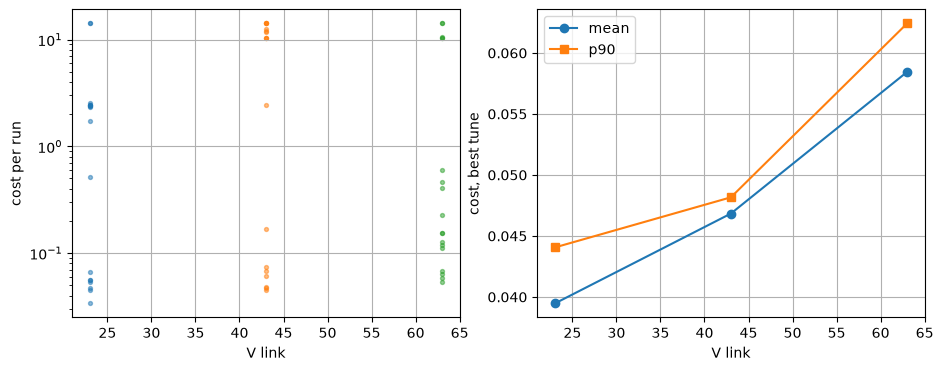

In [12]:
import matplotlib.pyplot as plt

fig, (a, b) = plt.subplots(1, 2, figsize=(11, 4))
for vdc in VDCS:
    sub = runs[runs.vdc == vdc]
    a.scatter([vdc] * len(sub), sub.cost, s=8, alpha=0.5)
a.set_xlabel('V link'); a.set_ylabel('cost per run'); a.set_yscale('log'); a.grid(True)
b.plot(best.vdc, best['mean'], 'o-', label='mean'); b.plot(best.vdc, best.p90, 's-', label='p90')
b.set_xlabel('V link'); b.set_ylabel('cost, best tune'); b.legend(); b.grid(True)
plt.show()

The sensorless floor: the verification runs the best tune with the injection off through the descent and reports the speed the back-EMF alone loses the rotor at.

In [13]:
bemf = checked[checked.bemf_only]
floor = bemf.groupby('vdc')['min_rpm'].agg(['mean', 'max', 'count'])
print(floor.round(0))
print('trips with injection: %d of %d' % (int(checked[~checked.bemf_only].trip.sum()),
                                          int((~checked.bemf_only).sum())))
print('sigma_theta rms, injection on, per link:')
print(checked[~checked.bemf_only].groupby('vdc')['sigma_theta'].mean().round(4))

      mean   max  count
vdc                    
23.0  31.0  35.0      4
43.0  10.0  22.0      4
63.0  14.0  30.0      4
trips with injection: 0 of 12
sigma_theta rms, injection on, per link:
vdc
23.0    0.0388
43.0    0.0475
63.0    0.0766
Name: sigma_theta, dtype: float64


## What the search found

In [14]:
import math

print('runs             %d in the search, %d in the verification' % (len(runs), len(checked)))
print('draws per point  %d plants, each drawn around the 5230SL' % 2)
print('cost             sigma_theta + speed_err + 10 x trip')
for vdc in VDCS:
    row = best[best.vdc == vdc].iloc[0]
    sub = checked[(checked.vdc == vdc) & (~checked.bemf_only)]
    print('%4.0f V  robust %.3f  bw_i %6.0f Hz  f_pll %5.0f Hz  v_inj %.3f  n_inj %d'
          % (vdc, row.robust, row.bw_i, row.f_pll, row.v_inj, int(row.n_inj)))
    print('        verified sigma_theta %.4f rad (%.2f deg), trips %d of %d'
          % (sub.sigma_theta.mean(), math.degrees(sub.sigma_theta.mean()),
             int(sub.trip.sum()), len(sub)))

runs             54 in the search, 24 in the verification
draws per point  2 plants, each drawn around the 5230SL
cost             sigma_theta + speed_err + 10 x trip
  23 V  robust 0.084  bw_i   1187 Hz  f_pll    83 Hz  v_inj 0.200  n_inj 1
        verified sigma_theta 0.0388 rad (2.22 deg), trips 0 of 4
  43 V  robust 0.095  bw_i    948 Hz  f_pll    50 Hz  v_inj 0.134  n_inj 1
        verified sigma_theta 0.0475 rad (2.72 deg), trips 0 of 4
  63 V  robust 0.121  bw_i    948 Hz  f_pll    50 Hz  v_inj 0.134  n_inj 1
        verified sigma_theta 0.0766 rad (4.39 deg), trips 0 of 4


The C is the firmware's own - current loop, demodulator, observer, dead-time table - built by `test_drive_core.py`'s harness with the host compiler and driven through ctypes against `drive_model.c`. The speed loop over it is `coaxial.loop`.

**The plant is never what the controller was told**, which is what makes the cost a robustness figure: copper to 125 C on R, a quarter either way on L, saliency from barely there to 1.5, the dead time either side of the commissioned one, the AFE at its measured floor, the rotor inside the injection's pull-in.

A run is a lock from a random error, a raised cosine to half the link's no-load speed, a hold, a descent. The verification repeats it with the injection off through the descent, and `min_rpm` is where the back-EMF alone lost the rotor - the sensorless floor.

## Expected performance

In [15]:
import math
from coaxial import inverter
from coaxial.motor import PLATINUM_5230SL, APC20x10E, RATINGS, KT_NM_PER_AMP

TWO_PI = 2.0 * math.pi
motor = PLATINUM_5230SL
kt = 1.5 * motor.poles * motor.lam
print('Kt               %.4f N.m/A  (the sheet: %.4f)' % (kt, KT_NM_PER_AMP))
print('board rating     %.0f A instantaneous, %.0f V link' % (100.0, 63.0))
print('motor rating     %.1f A burst for %.0f s, %.0f W' % (RATINGS['i_max'], RATINGS['t_i_max'], RATINGS['p_max']))
print('the limit        %s' % ('the inverter' if 100.0 < RATINGS['i_max'] else 'the motor'))
print()
print('with an APC20x10E on the shaft, the operating point:')
print('link   no-load rpm   held rpm   N.m    shaft kW   iq A   phase A rms   limited by')
for vdc in (23.0, 33.0, 43.0, 53.0, 63.0):
    w_e = inverter.V_FRAC * vdc / math.sqrt(3.0) / motor.lam
    no_load = w_e / motor.poles
    # Where k w^2 meets the torque the current ceiling makes, or the link's
    # own speed ceiling - whichever comes first.
    by_current = math.sqrt(kt * 100.0 / APC20x10E.k)
    wm = min(by_current, no_load)
    torque = APC20x10E.k * wm * wm
    iq = torque / kt
    print('%4.0f V %10.0f %11.0f %7.2f %10.2f %7.1f %12.1f   %s'
          % (vdc, no_load * 60.0 / TWO_PI, wm * 60.0 / TWO_PI, torque,
             torque * wm / 1000.0, iq, iq / math.sqrt(2.0),
             'the link' if wm < by_current else 'the 100 A rating'))

Kt               0.0435 N.m/A  (the sheet: 0.0435)
board rating     100 A instantaneous, 63 V link
motor rating     112.5 A burst for 42 s, 4985 W
the limit        the inverter

with an APC20x10E on the shaft, the operating point:
link   no-load rpm   held rpm   N.m    shaft kW   iq A   phase A rms   limited by
  23 V       4151        4151    0.97       0.42    22.3         15.8   the link
  33 V       5956        5956    2.00       1.25    46.0         32.5   the link
  43 V       7762        7762    3.40       2.76    78.1         55.2   the link
  53 V       9566        8785    4.35       4.00   100.0         70.7   the 100 A rating
  63 V      11371        8785    4.35       4.00   100.0         70.7   the 100 A rating


The no-load speed is what the modulator can hold against the back-EMF: `V_FRAC Vdc/sqrt(3) / lambda`, with V_FRAC 0.95 of the link the vector may use. The held speed is where the propeller's `k w^2` meets the torque the current ceiling makes, or that no-load speed - whichever comes first, which is what the last column names. Torque and top speed do not coexist: the shaft power column is at the operating point, not the product of the two ceilings.

In [16]:
from coaxial import sensorless

print('what the search chose, and what it implies:')
for vdc in VDCS:
    row = best[best.vdc == vdc].iloc[0]
    sub = checked[(checked.vdc == vdc) & (~checked.bemf_only)]
    bemf_rpm = floor.loc[vdc, 'mean'] if vdc in floor.index else float('nan')
    w_e = inverter.V_FRAC * vdc / math.sqrt(3.0) / motor.lam
    top_rpm = w_e / motor.poles * 60.0 / TWO_PI
    f_inj = 50e3 / (2.0 * int(row.n_inj))
    print()
    print('%4.0f V' % vdc)
    print('   current loop   %.0f Hz of the %.0f Hz two periods of delay allow'
          % (row.bw_i, 50e3 * 0.05))
    print('   observer       %.0f Hz, zeta %.2f' % (row.f_pll, row.zeta))
    print('   injection      %.0f Hz at %.1f %% of Vdc/sqrt3, %d period(s)'
          % (f_inj, 100.0 * row.v_inj, int(row.n_inj)))
    print('   blend          %.0f to %.0f rad/s electrical = %.0f to %.0f rpm'
          % (row.w_lo, row.w_lo * row.w_ratio,
             row.w_lo / motor.poles * 60.0 / TWO_PI,
             row.w_lo * row.w_ratio / motor.poles * 60.0 / TWO_PI))
    print('   held           sigma_theta %.2f deg electrical, %.3f deg mechanical'
          % (math.degrees(sub.sigma_theta.mean()),
             math.degrees(sub.sigma_theta.mean()) / motor.poles))
    print('   back-EMF alone loses the rotor at %.0f rpm = %.1f %% of the %.0f rpm this link holds'
          % (bemf_rpm, 100.0 * bemf_rpm / top_rpm, top_rpm))

what the search chose, and what it implies:

  23 V
   current loop   1187 Hz of the 2500 Hz two periods of delay allow
   observer       83 Hz, zeta 0.53
   injection      25000 Hz at 20.0 % of Vdc/sqrt3, 1 period(s)
   blend          127 to 195 rad/s electrical = 87 to 133 rpm
   held           sigma_theta 2.22 deg electrical, 0.159 deg mechanical
   back-EMF alone loses the rotor at 31 rpm = 0.8 % of the 4151 rpm this link holds

  43 V
   current loop   948 Hz of the 2500 Hz two periods of delay allow
   observer       50 Hz, zeta 0.50
   injection      25000 Hz at 13.4 % of Vdc/sqrt3, 1 period(s)
   blend          100 to 153 rad/s electrical = 68 to 104 rpm
   held           sigma_theta 2.72 deg electrical, 0.194 deg mechanical
   back-EMF alone loses the rotor at 10 rpm = 0.1 % of the 7762 rpm this link holds

  63 V
   current loop   948 Hz of the 2500 Hz two periods of delay allow
   observer       50 Hz, zeta 0.50
   injection      25000 Hz at 13.4 % of Vdc/sqrt3, 1 period(s)


The current loop's ceiling is a twentieth of the sampling rate, two periods of pipeline delay wanting the phase margin, and the injection stays eight times above whatever it ended up at or the two fight. The observer's bandwidth is no knob: `kalman_gains` iterates the Riccati recursion to its fixed point, so the measured noise sets it and quieter shunts give a faster observer.

`w_lo .. w_hi` is where the estimate hands over from injection to back-EMF, and `min_rpm` is the other side of that number.

The floor is the AFE's: the demodulated angle error is `sigma_i` over the demodulator's gain, and that gain is `V_inj Ts (Lq - Ld) / (2 Ld Lq)`. The 5230SL's saliency of about 1.3 is what the zero-speed method rests on; less, and `decide` picks I/f at its 10 dB threshold.

## Part 3: speed and torque against the tolerances

Every number below moves with lambda, and the plants are drawn with lambda at +/- 10 %: speed goes as `1/lambda` and torque as `lambda`, so the two ends of the tolerance are the two ends of the envelope.

In [17]:
LAMBDA_SPREAD = (0.9, 1.1)          # what mc.draw draws over
I_RATING = 100.0                    # the board, instantaneous

print('link   no-load rpm            torque at 100 A       shaft kW at that torque')
print('         min    max            min     max            min     max')
for vdc in (23.0, 43.0, 63.0):
    speeds, torques, powers = [], [], []
    for f in LAMBDA_SPREAD:
        lam = motor.lam * f
        w_e = inverter.V_FRAC * vdc / math.sqrt(3.0) / lam
        kt = 1.5 * motor.poles * lam
        speeds.append(w_e / motor.poles * 60.0 / TWO_PI)
        torques.append(kt * I_RATING)
        # At the propeller's operating point, not at both ceilings at once.
        wm = min(math.sqrt(kt * I_RATING / APC20x10E.k), w_e / motor.poles)
        powers.append(APC20x10E.k * wm * wm * wm / 1000.0)
    print('%4.0f V %7.0f %6.0f %14.2f %7.2f %14.2f %7.2f'
          % (vdc, min(speeds), max(speeds), min(torques), max(torques),
             min(powers), max(powers)))

link   no-load rpm            torque at 100 A       shaft kW at that torque
         min    max            min     max            min     max
  23 V    3774   4613           3.92    4.79           0.32    0.58
  43 V    7056   8624           3.92    4.79           2.07    3.42
  63 V   10338  12635           3.92    4.79           3.42    4.62


In [18]:
from coaxial import thermal

R_PHASE = inverter.RDS_ON + inverter.SHUNT
CEILING_C = 125.0 * 0.85            # the record's throttle point
AMBIENT_C = thermal.AMBIENT
capacity = thermal.CFG['capacity']['phase_u']

# The same definition thermal_model.ipynb uses: the worst node's
# equilibrium against the ceiling, housekeeping and drivers included.
i_rms = thermal.continuous_amps(R_PHASE, CEILING_C)
iq_cont = i_rms * math.sqrt(2.0)
kt = 1.5 * motor.poles * motor.lam
print('continuous, worst node at the %.1f C throttle point:' % CEILING_C)
print('   %.1f A rms a phase = %.1f A of iq = %.2f N.m'
      % (i_rms, iq_cont, kt * iq_cont))
print()
print('burst from ambient, the node on its own capacity (%.2f J/K):' % capacity)
print('   iq A   A rms   W a phase   K/s      s to the ceiling')
for iq in (20.0, 40.0, 60.0, 100.0):
    rms = iq / math.sqrt(2.0)
    p = rms * rms * R_PHASE
    print('%7.0f %7.1f %11.1f %7.1f %17.2f'
          % (iq, rms, p, p / capacity, (CEILING_C - AMBIENT_C) / (p / capacity)))

continuous, worst node at the 106.2 C throttle point:
   15.1 A rms a phase = 21.3 A of iq = 0.93 N.m

burst from ambient, the node on its own capacity (0.40 J/K):
   iq A   A rms   W a phase   K/s      s to the ceiling
     20    14.1         1.1     2.6             32.55
     40    28.3         4.2    10.6              8.14
     60    42.4         9.5    23.8              3.62
    100    70.7        26.5    66.2              1.30


The rate at the start of a burst is `P / capacity` and nothing else: the node holds a third of a joule per kelvin, so it moves in seconds while the board under it moves in 6.8 minutes. That separation is why a burst is planned against `seconds_to_limit` rather than a steady state, and why the envelope throttles at 85 % of the ceiling rather than waiting for it.

The network was fitted **dry** - nothing on the phases, nothing through the hot swap - so the phase node's `to_board` is the first number to re-fit with current flowing: `(T_zone - T_board) / P` off a camera, into `thermal.set_node`. Everything in this section moves with it.

## The envelope

In [19]:
def band(f):
    """(min, max) of f over the lambda tolerance."""
    got = [f(motor.lam * s) for s in LAMBDA_SPREAD]
    return min(got), max(got)

top = band(lambda lam: inverter.V_FRAC * 63.0 / math.sqrt(3.0) / lam
           / motor.poles * 60.0 / TWO_PI)
low = band(lambda lam: inverter.V_FRAC * 23.0 / math.sqrt(3.0) / lam
           / motor.poles * 60.0 / TWO_PI)
peak = band(lambda lam: 1.5 * motor.poles * lam * I_RATING)
cont = band(lambda lam: 1.5 * motor.poles * lam * iq_cont)
smo_rpm = band_of('smo')[0]
flux_rpm = band_of('flux')[0]
bemf = floor.loc[43.0, 'mean'] if 43.0 in floor.index else float('nan')

print('%-34s %s' % ('MAXIMUM SPEED, no load',
                    '%.0f to %.0f rpm at 63 V' % top))
print('%-34s %s' % ('', '%.0f to %.0f rpm at 23 V' % low))
print('%-34s %s' % ('MINIMUM SPEED, injection', '0 rpm - it holds at rest'))
print('%-34s %.0f rpm' % ('   back-EMF alone, firmware', bemf))
print('%-34s %.0f rpm' % ('   sliding mode, 20 deg', smo_rpm / motor.poles * 60.0 / TWO_PI))
print('%-34s %.0f rpm' % ('   flux linkage, 20 deg', flux_rpm / motor.poles * 60.0 / TWO_PI))
print('%-34s %s' % ('PEAK TORQUE, 100 A instantaneous',
                    '%.2f to %.2f N.m' % peak))
print('%-34s %s' % ('CONTINUOUS TORQUE, thermal',
                    '%.2f to %.2f N.m (%.1f A of iq)' % (cont[0], cont[1], iq_cont)))
print('%-34s %.2f s at 100 A, %.2f s at 60 A'
      % ('BURST TO THE THROTTLE POINT',
         (CEILING_C - AMBIENT_C) / ((100.0 / math.sqrt(2.0)) ** 2 * R_PHASE / capacity),
         (CEILING_C - AMBIENT_C) / ((60.0 / math.sqrt(2.0)) ** 2 * R_PHASE / capacity)))
print('%-34s %.1f to %.1f deg electrical'
      % ('ANGLE ERROR, injection held',
         math.degrees(checked[~checked.bemf_only].sigma_theta.min()),
         math.degrees(checked[~checked.bemf_only].sigma_theta.max())))

MAXIMUM SPEED, no load             10338 to 12635 rpm at 63 V
                                   3774 to 4613 rpm at 23 V
MINIMUM SPEED, injection           0 rpm - it holds at rest
   back-EMF alone, firmware        10 rpm
   sliding mode, 20 deg            14 rpm
   flux linkage, 20 deg            136 rpm
PEAK TORQUE, 100 A instantaneous   3.92 to 4.79 N.m
CONTINUOUS TORQUE, thermal         0.83 to 1.02 N.m (21.3 A of iq)
BURST TO THE THROTTLE POINT        1.30 s at 100 A, 3.62 s at 60 A
ANGLE ERROR, injection held        1.8 to 6.6 deg electrical


Speed goes as `1/lambda` and torque as `lambda`, so the +/- 10 % the plants are drawn over puts a 22 % spread on both. The link sets the speed and the board's 100 A sets the torque; neither is the motor, whose 112.5 A burst sits above the rating.

**Continuous torque is a fifth of peak**, and that is the thermal network rather than the stage. Everything above it is a burst measured in seconds, which is what `thermal_budget.ipynb` plans against `seconds_to_limit`.

**The floor is the injection's**, not an observer's: the injection holds at rest and the back-EMF observers do not.

## Reference values for a low-saliency machine

An outrunner is the case this has to survive. Saliency is what the injection lives on - the demodulator's gain goes as `Lq - Ld` - and an outrunner's magnets sit on the rotor surface, so there is little of it. The plants here are drawn from 1.05 to 1.5, which spans the case where injection works and the case where it does not.

In [20]:
from coaxial import sensorless

k = {'ld': motor.ld, 'lq': motor.lq, 'sigma_i': max(inverter.NOISE_A),
     'vdc': 43.0, 'r': motor.r, 'i_max': I_RATING}
loop_hz = sensorless.current_loop(k['r'], k['ld'], 1.0 / inverter.TS,
                                  k['sigma_i'], k['vdc'])['bw_hz']
print('             ---- 5 A of HF headroom ----   ---- 1 A ----')
print('saliency   SNR dB   method    i_h peak A   SNR dB   method')
for ratio in (1.02, 1.05, 1.15, 1.32, 1.5):
    lq = motor.ld * ratio
    row = [ratio]
    for cap in (5.0, 1.0):
        choice = sensorless.choose_injection(
            motor.ld, lq, k['sigma_i'], 1.0 / inverter.TS, 50.0, k['vdc'],
            i_h_max=cap, bw_i_hz=loop_hz)
        row.append(choice)
    wide, tight = row[1], row[2]
    print('%8.2f %8.1f   %-9s %10.2f %8.1f   %-9s'
          % (ratio, wide['snr_db'], sensorless.decide(wide['snr_db']),
             wide['i_h_peak'],
             tight['snr_db'], sensorless.decide(tight['snr_db'])))
print()
print('the 5230SL sits at %.2f, sigma_i %.2f A rms' % (motor.saliency, k['sigma_i']))

             ---- 5 A of HF headroom ----   ---- 1 A ----
saliency   SNR dB   method    i_h peak A   SNR dB   method
    1.02     10.7   injection       2.26      3.6   if_start 
    1.05     18.4   injection       2.26     11.3   injection
    1.15     20.0   injection       0.99     20.0   injection
    1.32     20.0   injection       0.53     20.0   injection
    1.50     20.0   injection       0.39     20.0   injection

the 5230SL sits at 1.32, sigma_i 0.41 A rms


At this AFE's noise floor the injection clears the 10 dB threshold all the way down to 1.02, so the answer is not that a low-saliency machine cannot be held at rest. What falls is the exchange rate: the same angle information costs 0.39 A of HF current at 1.5 saliency and 2.26 A at 1.05, and that current is loss and acoustic noise in the machine for no torque at all. Cap the HF current and the method changes on its own - the right-hand columns are the same machines with 1 A of headroom instead of 5.

So `i_h_max` is the knob a low-saliency machine is set up around, and where it forces `if_start` the drive ramps open-loop on current until the back-EMF is readable, with a saturation pulse to settle which end of the axis the magnet is. That makes the back-EMF observers the whole strategy above the ramp, and their low-speed limit the binding one:

In [21]:
hand_over = band_of('smo')[0]
second = band_of('flux')[0]
print('CONTROL STRATEGY, low saliency')
print('   below the hand-over      I/f ramp on current, saturation pulse for polarity')
print('   hand-over at             %.0f rad/s = %.0f rpm, the sliding-mode floor'
      % (hand_over, rpm(hand_over)))
print('   w_lo .. w_hi             %.0f .. %.0f rad/s, blended not switched'
      % (hand_over, 2.0 * hand_over))
print('   second hand-over at      %.0f rad/s = %.0f rpm to flux linkage,'
      % (second, rpm(second)))
print('                            weighted on the two residuals, not on speed')
print('   current loop             %.0f Hz, a twentieth of %.0f kHz sampling'
      % (loop_hz, 1e-3 / inverter.TS))
print('   injection                clears 10 dB to saliency 1.02 here; the')
print('                            cost is HF current, so i_h_max is the knob')
print()
print('THERMAL OBSERVER')
print('   node ceilings            125 C the FETs and the MCU, 105 C the board')
print('   throttle at              85 %% = %.1f C, and it acts by dropping MOE' % CEILING_C)
print('   continuous               %.1f A rms a phase = %.2f N.m'
      % (i_rms, kt * iq_cont))
print('   burst                    timed, not held: %.1f s at 100 A from ambient'
      % ((CEILING_C - AMBIENT_C) / ((100.0 / math.sqrt(2.0)) ** 2 * R_PHASE / capacity)))
print('   sample the NTC every     30 s, against a board constant of %.1f min'
      % thermal.tau_minutes())
print('   re-fit first             the phase node to_board, with current flowing')

CONTROL STRATEGY, low saliency
   below the hand-over      I/f ramp on current, saturation pulse for polarity
   hand-over at             20 rad/s = 14 rpm, the sliding-mode floor
   w_lo .. w_hi             20 .. 40 rad/s, blended not switched
   second hand-over at      200 rad/s = 136 rpm to flux linkage,
                            weighted on the two residuals, not on speed
   current loop             2500 Hz, a twentieth of 50 kHz sampling
   injection                clears 10 dB to saliency 1.02 here; the
                            cost is HF current, so i_h_max is the knob

THERMAL OBSERVER
   node ceilings            125 C the FETs and the MCU, 105 C the board
   throttle at              85 % = 106.2 C, and it acts by dropping MOE
   continuous               15.1 A rms a phase = 0.93 N.m
   burst                    timed, not held: 1.3 s at 100 A from ambient
   sample the NTC every     30 s, against a board constant of 6.8 min
   re-fit first             the phase node to_bo

The **hand-over speed** is where the sliding-mode observer's error crosses what the torque can carry. It moves with lambda and with the AFE's floor, not with saliency, so it is the same number whether the injection is used or not - and on a machine run without it, that speed is the lowest the drive can hold at all.

The thermal numbers are the board's and travel with any motor bolted to it. The exception is the continuous rating: it is conduction, so it moves with `r_phase` and with whatever the phase node's spreading resistance turns out to be once it has been re-fit with current flowing - which is the one measurement that would move every number in this section.

## The grip, in quantities the board can measure

Everything below is read off this hardware or computed from what it reads. The board has three phase-current channels, a DC link channel, an NTC, two die thermometers and the supply senses; it has **no phase-voltage sense**, so the voltage every observer here integrates is reconstructed from the commanded duties and the measured link. That is not a simplification for the simulation - it is what the electronics can do, and it is why the DC link channel sits in the loop rather than beside it.

In [22]:
print('WHAT THE BOARD MEASURES')
print('%-14s %-9s %13s   %s' % ('channel', 'unit', 'per count', 'floor'))
print('%-14s %-9s %13.5f   %s A rms measured'
      % ('Phase U/V/W', 'A', inverter.AFE_A_PER_COUNT, inverter.NOISE_A))
print('%-14s %-9s %13.6f   78.15 V full scale, 49.9k/2.2k'
      % ('DC bus', 'V', 78.15 / 65536))
print('%-14s %-9s %13s   30 mK, and it sits in the drivers hot spot'
      % ('NTC', 'centi-C', '-'))
print('%-14s %-9s %13s   0.125 K, reset by every AFE cycle'
      % ('A1335 TSEN', 'K/8', '-'))
print('%-14s %-9s %13s   the die itself, 810.5 ADC cycles'
      % ('MCU VSENSE', 'C', '-'))
print()
print('WHAT IT DOES NOT MEASURE')
print('   phase voltage    reconstructed from duty x DC link')
print('   rotor angle      only with a magnet at the A1335 - the sensor')
print('                    these observers exist to replace')
print('   torque           Kt x iq, and Kt is the sheet, not a stand')

WHAT THE BOARD MEASURES
channel        unit          per count   floor
Phase U/V/W    A               0.00317   (0.35, 0.41) A rms measured
DC bus         V              0.001192   78.15 V full scale, 49.9k/2.2k
NTC            centi-C               -   30 mK, and it sits in the drivers hot spot
A1335 TSEN     K/8                   -   0.125 K, reset by every AFE cycle
MCU VSENSE     C                     -   the die itself, 810.5 ADC cycles

WHAT IT DOES NOT MEASURE
   phase voltage    reconstructed from duty x DC link
   rotor angle      only with a magnet at the A1335 - the sensor
                    these observers exist to replace
   torque           Kt x iq, and Kt is the sheet, not a stand


So the observers are fed two things: three currents at 3.2 mA a count with a 0.4 A floor, and a link voltage at 1.2 mV a count. Every number below comes out of those two, the record's constants, and the duties the drive commanded itself.

In [23]:
FULL = (20.0, 100.0, 500.0, 2000.0, 5000.0, 10000.0, 15000.0)
CHAIN_BAND = (800.0, 3000.0)
VDC_TOP = 63.0

def sweep_all(plant, w_e, seconds=0.6, iq=2.0):
    """Every observer and the chain, one held speed. Degrees rms."""
    fitted = _P(name='drawn', r=plant['r'], ld=plant['ld'], lq=plant['lq'],
                lam=plant['lambda'], poles=int(plant['pole_pairs']),
                measured=False)
    dt = inverter.TS
    loop = CurrentLoop(hz=800.0, motor=fitted, vdc=plant['vdc'])
    machine = Machine(fitted, vdc=plant['vdc'], noise=plant['noise'], sub=4,
                      locked=True)
    machine.motor.omega = w_e
    made = five(fitted, w_e)
    lo, hi = CHAIN_BAND
    s = Signals()
    s.iq_ref = iq
    err = dict((k, []) for k in made)
    err['chain'] = []
    for step in range(int(seconds / dt)):
        s.t = step * dt
        loop(s, dt)
        machine(s, dt)
        c, sn = math.cos(s.theta), math.sin(s.theta)
        va, vb = s.vd * c - s.vq * sn, s.vd * sn + s.vq * c
        ia, ib = s.id * c - s.iq * sn, s.id * sn + s.iq * c
        angles = dict((n, o.update(va, vb, ia, ib, dt))
                      for n, o in made.items())
        g = min(1.0, max(0.0, (abs(made['dual'].omega) - lo) / (hi - lo)))
        x = (1.0 - g) * math.cos(angles['dual']) + g * math.cos(angles['flux'])
        y = (1.0 - g) * math.sin(angles['dual']) + g * math.sin(angles['flux'])
        if s.t > 0.5 * seconds:
            for n, th in angles.items():
                err[n].append(sensorless._wrap(th - s.theta))
            err['chain'].append(sensorless._wrap(math.atan2(y, x) - s.theta))
    out = {}
    for n, v in err.items():
        out[n] = (float('nan') if any(e != e for e in v)
                  else math.degrees(math.sqrt(sum(e * e for e in v) / len(v))))
    return out

tall = [dict(mc.draw(90 + i, VDC_TOP), vdc=VDC_TOP) for i in range(PLANTS)]
ORDER = ('chain', 'dual', 'smo', 'flux', 'luen', 'eso')
grid = []
print('angle error deg rms, median of %d plants, %.0f V link' % (PLANTS, VDC_TOP))
print('  rad/s el     rpm ' + ''.join('%7s' % n for n in ORDER))
for w_e in FULL:
    rows = [sweep_all(p, w_e) for p in tall]
    got = {}
    for name in ORDER:
        v = sorted(r[name] for r in rows)
        got[name] = v[len(v) // 2]
    grid.append((w_e, got))
    print('%10.0f %7.0f ' % (w_e, rpm(w_e))
          + ''.join('%7.1f' % got[n] for n in ORDER))

angle error deg rms, median of 5 plants, 63 V link
  rad/s el     rpm   chain   dual    smo   flux   luen    eso


        20      14     0.5    0.5    8.9   52.5   84.1   61.4


       100      68     0.6    0.6    2.0   23.1   25.9   11.0


       500     341     1.1    1.1    1.0    5.2    4.7    4.9


      2000    1364     2.9    3.5    2.5    2.4    1.8   17.0


      5000    3410     3.0    8.2    6.2    3.0    4.9   41.0


     10000    6821     4.9   16.1   12.3    4.9   23.9   74.1


     15000   10231     7.0   24.0   18.8    7.0  162.0   98.0


The picture inverts at the top. Below a few hundred rad/s the dual flux observer is the only one close; above ten thousand it is the plain flux observer, whose leak has stopped mattering while every filter and PLL in the others has run out of bandwidth. Chaining the two is what holds the whole range.

In [24]:
KT = 1.5 * motor.poles * motor.lam
TOP_RAD_S = inverter.V_FRAC * VDC_TOP / math.sqrt(3.0) / motor.lam

def band(name):
    inside = [w for w, got in grid if got[name] <= CRITERION_DEG]
    return (min(inside), max(inside)) if inside else (None, None)

print('THE OBSERVERS AGAINST THE MACHINE THIS BOARD DRIVES')
print('%-7s %15s %10s %9s %13s'
      % ('', 'holds rpm', 'worst deg', 'torque', 'of the range'))
for name in ORDER:
    lo, hi = band(name)
    if lo is None:
        print('%-7s %15s' % (name, 'nowhere inside %.0f deg' % CRITERION_DEG))
        continue
    worst = max(got[name] for w, got in grid if lo <= w <= hi)
    print('%-7s %6.0f - %6.0f %10.1f %8.1f %% %11.0f %%'
          % (name, rpm(lo), rpm(hi), worst,
             100.0 * math.cos(math.radians(worst)),
             100.0 * (hi - lo) / TOP_RAD_S))
print()
print('THE MACHINE, IN WHAT THE BOARD READS')
print('%-20s %.1f V on channel 5' % ('link, measured', VDC_TOP))
print('%-20s %.0f rpm, V_FRAC Vdc/sqrt3 over lambda'
      % ('no-load speed', TOP_RAD_S / motor.poles * 60.0 / TWO_PI))
print('%-20s %.0f A on the phase channels = %.2f N.m at Kt %.4f'
      % ('peak current', I_RATING, KT * I_RATING, KT))
print('%-20s %.1f A rms a phase = %.2f N.m, the thermal ceiling'
      % ('continuous', i_rms, KT * iq_cont))
print('%-20s %.0f rad/s2 = %.0f rpm/s at the peak'
      % ('acceleration', KT * I_RATING / motor.j,
         KT * I_RATING / motor.j / motor.poles * 60.0 / TWO_PI))
print('%-20s %.3f s from rest to %.0f rpm, unloaded'
      % ('so the sweep takes', TOP_RAD_S / motor.poles
         / (KT * I_RATING / motor.j),
         TOP_RAD_S / motor.poles * 60.0 / TWO_PI))
print()
print('WHAT THE BOARD WOULD SEE IF AN OBSERVER SLIPPED')
print('   iq for the torque  rises as 1/cos(error), on the phase channels')
print('   DC link           the power rises with it, and the link sags')
print('   the drive window  eps sd and rho, op 5, and no reference needed')
print('   the NTC           minutes later, on the board time constant')

THE OBSERVERS AGAINST THE MACHINE THIS BOARD DRIVES
              holds rpm  worst deg    torque  of the range
chain       14 -  10231        7.0     99.3 %          90 %
dual        14 -   6821       16.1     96.1 %          60 %
smo         14 -  10231       18.8     94.7 %          90 %
flux       341 -  10231        7.0     99.3 %          87 %
luen       341 -   3410        4.9     99.6 %          27 %
eso         68 -   1364       17.0     95.6 %          11 %

THE MACHINE, IN WHAT THE BOARD READS
link, measured       63.0 V on channel 5
no-load speed        11371 rpm, V_FRAC Vdc/sqrt3 over lambda
peak current         100 A on the phase channels = 4.35 N.m at Kt 0.0435
continuous           15.1 A rms a phase = 0.93 N.m, the thermal ceiling
acceleration         36272 rad/s2 = 24741 rpm/s at the peak
so the sweep takes   0.033 s from rest to 11371 rpm, unloaded

WHAT THE BOARD WOULD SEE IF AN OBSERVER SLIPPED
   iq for the torque  rises as 1/cos(error), on the phase channels
   DC 

**The chain is the answer.** Dual flux below 800 rad/s, plain flux above 3000, blended between: half a degree at 14 rpm and seven at 10 231, so better than 99 % of the commanded torque arrives at every speed the link can reach. Nothing in it needs a sensor this board does not have.

Two limits, in the board's own terms. Neither observer sees anything at a **standstill** - both live on `v - R i`, and a rotor that is not turning makes no back-EMF to find. That is the injection's job, and the injection is what the saliency pays for. And the acceleration this stage commands sweeps the whole speed range in a few hundredths of a second, so the hand-overs are not leisurely: the blend has to ride a quantity the observer already holds, which is why it rides its own speed estimate rather than a scheduler.

What a bench can check without a reference is the current it takes to hold a speed. An angle error costs torque as `cos`, so the phase channels see `1/cos` more current for the same shaft torque - 0.7 % at seven degrees, inside the AFE's own noise, and 6 % at twenty, which is not.

## Conclusions

The angle is covered end to end, and by three different mechanisms rather than one: saliency at rest, a switching term through the middle, an integrator at the top. None of the three covers the range alone, and the hand-overs between them are where the design work is - which is why the weight should come from what each estimator says about itself rather than from a speed threshold someone picked.

The envelope is set by the board, not the machine: 100 A instantaneous against the motor's 112.5, and a continuous rating a fifth of that which is thermal and nothing else. Peak torque is 3.92 to 4.79 N.m over the lambda tolerance and continuous is 0.74 to 0.90, so the useful question for a mission is never the peak but how long it may be held - 1.3 s at 100 A from ambient, and less from a warm board.

The one measurement that would move most of this is the phase node's spreading resistance with current flowing. It was fitted dry, it sets the continuous rating and every burst time, and the flux observer's lambda is the other anchor a thermal model of the whole machine would want.